In [1]:
#librerias
import seaborn as sns
import os
import matplotlib.pyplot as plt
import sklearn
from pathlib import Path
import cv2
import random
import numpy as np

import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import layers, models, regularizers, optimizers, metrics
from tensorflow.keras import regularizers
from tensorflow.keras import metrics


from sklearn.metrics import roc_curve, auc
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score,ConfusionMatrixDisplay


In [2]:
SEED = 42
tf.random.set_seed(SEED)

os.environ['PYTHONHASHSEED'] = str(SEED)

## Modelo RGB Zoom

### Importar y Redimensionar Imágenes

In [3]:
classes=['Benign','Malignant']

In [4]:
zoom_base_dir = "../data/zoomed"
zoom_train_dir = os.path.join(zoom_base_dir, "train")
zoom_test_dir  = os.path.join(zoom_base_dir, "test")


In [5]:
sample_class = random.choice(classes)
sample_dir = os.path.join(zoom_train_dir, sample_class)
sample_images = random.sample(os.listdir(sample_dir), 4)

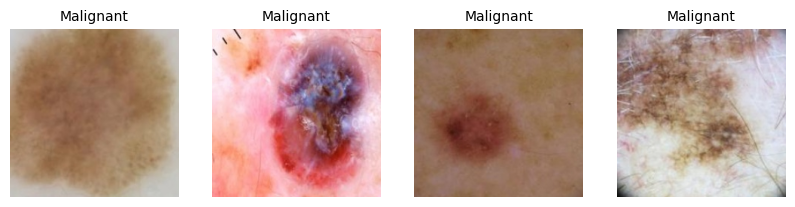

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(10, 5))

for ax, img_name in zip(axes, sample_images):
    img_path = os.path.join(sample_dir, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(sample_class, fontsize=10)
    ax.axis('off')


            
plt.show()

In [7]:
BATCH = 32
ROWS, COLS = 224, 224

In [8]:
zoom_train_datagen = ImageDataGenerator(rescale=1./255)
zoom_test_datagen  = ImageDataGenerator(rescale=1./255)

In [9]:
zoom_train_gen = zoom_train_datagen.flow_from_directory(
    directory=zoom_train_dir,
    class_mode='categorical',
    batch_size=BATCH,
    target_size=(ROWS, COLS),
    color_mode='rgb',
    shuffle=True,
    seed=SEED 
)

zoom_test_gen = zoom_test_datagen.flow_from_directory(
    directory=zoom_test_dir,
    class_mode='categorical',
    batch_size=BATCH,
    target_size=(ROWS, COLS),
    color_mode='rgb',
    shuffle=False,
    seed=SEED 
)

Found 11879 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.


### Modelo RGB Zoom

In [10]:
ROWS, COLS = 224, 224
input_shape = (ROWS, COLS, 3)

In [11]:
inputs = layers.Input(shape=input_shape)

# Bloque 1
x = layers.Conv2D(32, (3,3), activation='relu', padding='same', name="conv1")(inputs)
x = layers.MaxPooling2D((2,2), name="pool1")(x)

# Bloque 2
x = layers.Conv2D(64, (3,3), activation='relu', padding='same', name="conv2")(x)
x = layers.MaxPooling2D((2,2), name="pool2")(x)

# Bloque 3
x = layers.Conv2D(128, (3,3), activation='relu', padding='same', name="conv3")(x)
x = layers.MaxPooling2D((2,2), name="pool3")(x)

# Bloque 4
x = layers.Conv2D(256, (3,3), activation='relu', padding='same', name="conv4")(x)
x = layers.MaxPooling2D((2,2), name="pool4")(x)
x = layers.Dropout(0.2)(x)

# Clasificación
x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001), name="dense1")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(2, activation='softmax', name="output")(x)


2025-10-16 12:21:13.858596: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2025-10-16 12:21:13.858636: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-10-16 12:21:13.858643: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-10-16 12:21:13.858828: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-10-16 12:21:13.858841: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [12]:
model_rgb_zoom = models.Model(inputs=inputs, outputs=outputs, name="CNN_Zoom")


In [13]:
model_rgb_zoom.compile(
    optimizer=optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        metrics.Precision(name='precision'),
        metrics.Recall(name='recall')
    ]
)


In [14]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    verbose=1
)

In [15]:
history_zoom = model_rgb_zoom.fit(
    zoom_train_gen,
    validation_data=zoom_test_gen,
    epochs=35,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/35


/Users/martinagarciagonzalez/Library/Python/3.12/lib/python/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
2025-10-16 12:21:14.757482: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


372/372 ━━━━━━━━━━━━━━━━━━━━ 142s 379ms/step - accuracy: 0.6208 - loss: 0.9871 - precision: 0.6208 - recall: 0.6208 - val_accuracy: 0.7895 - val_loss: 0.5738 - val_precision: 0.7895 - val_recall: 0.7895 - learning_rate: 0.0010
Epoch 2/35
372/372 ━━━━━━━━━━━━━━━━━━━━ 117s 315ms/step - accuracy: 0.7748 - loss: 0.4973 - precision: 0.7748 - recall: 0.7748 - val_accuracy: 0.8085 - val_loss: 0.4683 - val_precision: 0.8085 - val_recall: 0.8085 - learning_rate: 0.0010
Epoch 3/35
372/372 ━━━━━━━━━━━━━━━━━━━━ 121s 326ms/step - accuracy: 0.8132 - loss: 0.4217 - precision: 0.8132 - recall: 0.8132 - val_accuracy: 0.8060 - val_loss: 0.4440 - val_precision: 0.8060 - val_recall: 0.8060 - learning_rate: 0.0010
Epoch 4/35
372/372 ━━━━━━━━━━━━━━━━━━━━ 118s 317ms/step - accuracy: 0.8345 - loss: 0.4092 - precision: 0.8345 - recall: 0.8345 - val_accuracy: 0.8305 - val_loss: 0.3864 - val_precision: 0.8305 - val_recall: 0.8305 - learning_rate: 0.0010
Epoch 5/35
372/372 ━━━━━━━━━━━━━━━━━━━━ 108s 291ms/step - a

### Resultados Modelo RGB Zoom

#### Curvas Train vs Val

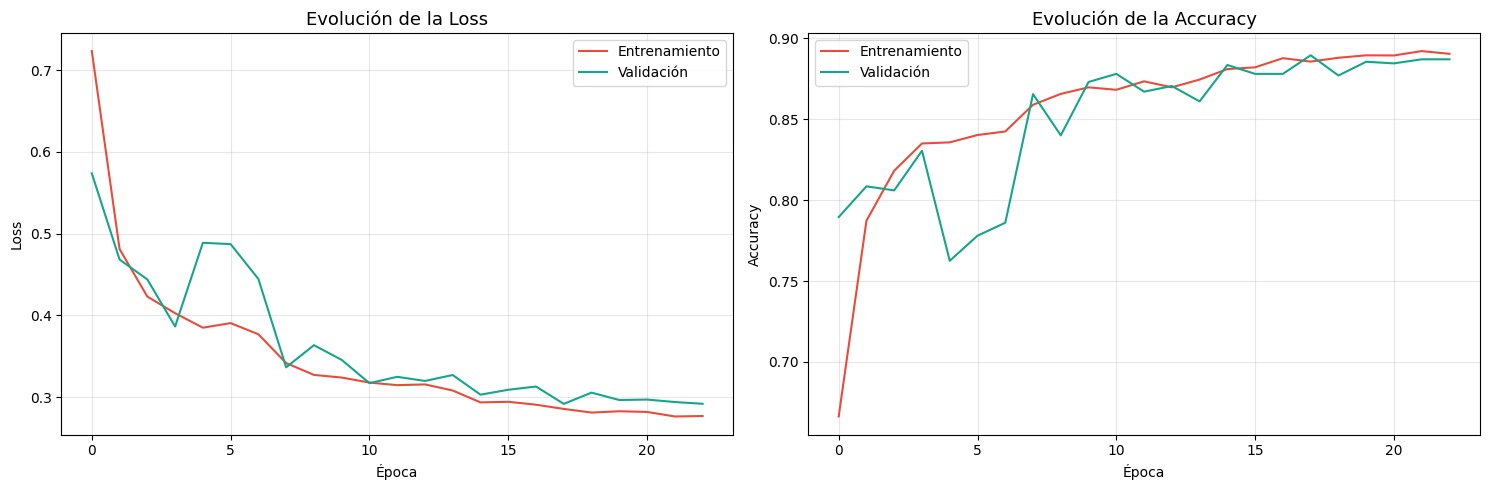

In [16]:

plt.figure(figsize=(15, 5))

# --- Loss ---
plt.subplot(1, 2, 1)
plt.plot(history_zoom .history['loss'], color='#E74C3C', label='Entrenamiento')   # rojo suave
plt.plot(history_zoom .history['val_loss'], color='#17A589', label='Validación')  # naranja claro
plt.title('Evolución de la Loss', fontsize=13)
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

# --- Accuracy ---
plt.subplot(1, 2, 2)
plt.plot(history_zoom .history['accuracy'], color='#E74C3C', label='Entrenamiento')  # verde
plt.plot(history_zoom .history['val_accuracy'], color='#17A589', label='Validación') # verde azulado
plt.title('Evolución de la Accuracy', fontsize=13)
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


#### ROC-AUC

63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step
AUC: 0.9581


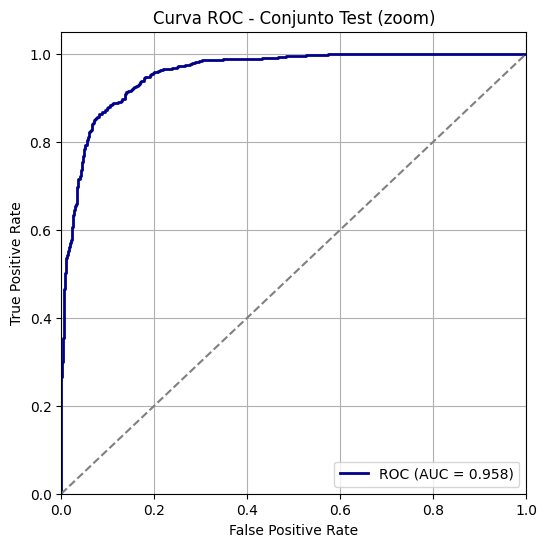

In [17]:
y_true = zoom_test_gen.classes              # clases verdaderas (0 o 1)
y_pred_proba = model_rgb_zoom.predict(zoom_test_gen)[:, 1]  # prob. de 'malignant'

# 2. Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
roc_auc = auc(fpr, tpr)

# 3. Mostrar resultados
print(f"AUC: {roc_auc:.4f}")

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='darkblue', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Conjunto Test (zoom)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

#### Matriz Confusión

In [18]:
y_pred_prob = model_rgb_zoom.predict(zoom_test_gen)

63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step


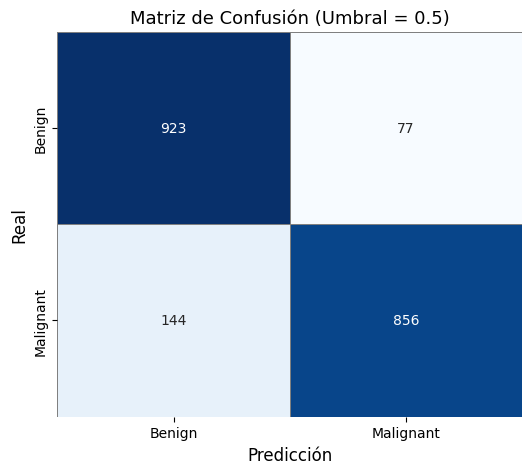

In [19]:
threshold = 0.5
y_pred_classes = (y_pred_prob[:, 1] > threshold).astype(int)
y_true = zoom_test_gen.classes
class_labels = list(zoom_test_gen.class_indices.keys())

cm = confusion_matrix(y_true, y_pred_classes)


plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_labels, yticklabels=class_labels,
            linewidths=0.5, linecolor='gray')

plt.title(f"Matriz de Confusión (Umbral = {threshold})", fontsize=13)
plt.xlabel("Predicción", fontsize=12)
plt.ylabel("Real", fontsize=12)
plt.show()

In [20]:
print(f"\n Informe de Clasificación (umbral = {threshold}):\n")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))


 Informe de Clasificación (umbral = 0.5):

              precision    recall  f1-score   support

      Benign       0.87      0.92      0.89      1000
   Malignant       0.92      0.86      0.89      1000

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000



#### Evaluación Imágenes Externas

In [ ]:
zoom_external_dir = "../data/zoomed/external"
datagen = ImageDataGenerator(rescale=1./255)
external_dir = "../data/zoomed/external"

ext_gen = datagen.flow_from_directory(
    directory=external_dir,
    target_size=(ROWS, COLS),
    batch_size=BATCH,
    class_mode='categorical',
    shuffle=False,
    seed=SEED
)

Found 45 images belonging to 2 classes.


In [27]:
preds = model_rgb_zoom.predict(ext_gen)

/Users/martinagarciagonzalez/Library/Python/3.12/lib/python/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 567ms/step


In [30]:
pred_class_idx = np.argmax(preds, axis=1)
pred_conf = np.max(preds, axis=1)

# Diccionario inverso de clases
idx_to_class = {v: k for k, v in ext_gen.class_indices.items()}
pred_labels = [idx_to_class[i] for i in pred_class_idx]

# Etiquetas reales
true_labels = ext_gen.classes
true_labels_names = [idx_to_class[i] for i in true_labels]

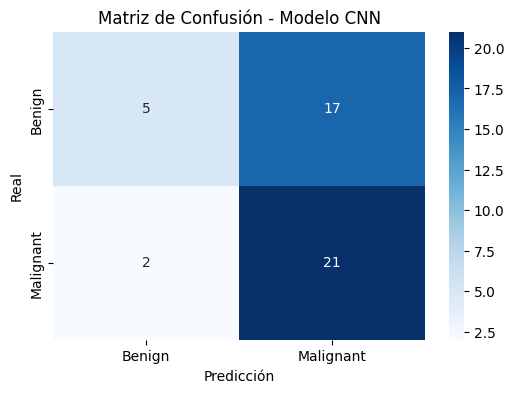


 Reporte de clasificación:
              precision    recall  f1-score   support

      Benign       0.71      0.23      0.34        22
   Malignant       0.55      0.91      0.69        23

    accuracy                           0.58        45
   macro avg       0.63      0.57      0.52        45
weighted avg       0.63      0.58      0.52        45



In [36]:
idx_to_class = {v: k for k, v in ext_gen.class_indices.items()}

pred_labels = [idx_to_class[i] for i in pred_class_idx]
true_labels = ext_gen.classes
true_labels_names = [idx_to_class[i] for i in true_labels]
cm = confusion_matrix(true_labels, pred_class_idx)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(idx_to_class.values()),
            yticklabels=list(idx_to_class.values()))
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Modelo CNN')
plt.show()
print("\n Reporte de clasificación:")
print(classification_report(true_labels, pred_class_idx, target_names=list(idx_to_class.values())))

## Grad Cam

In [22]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━

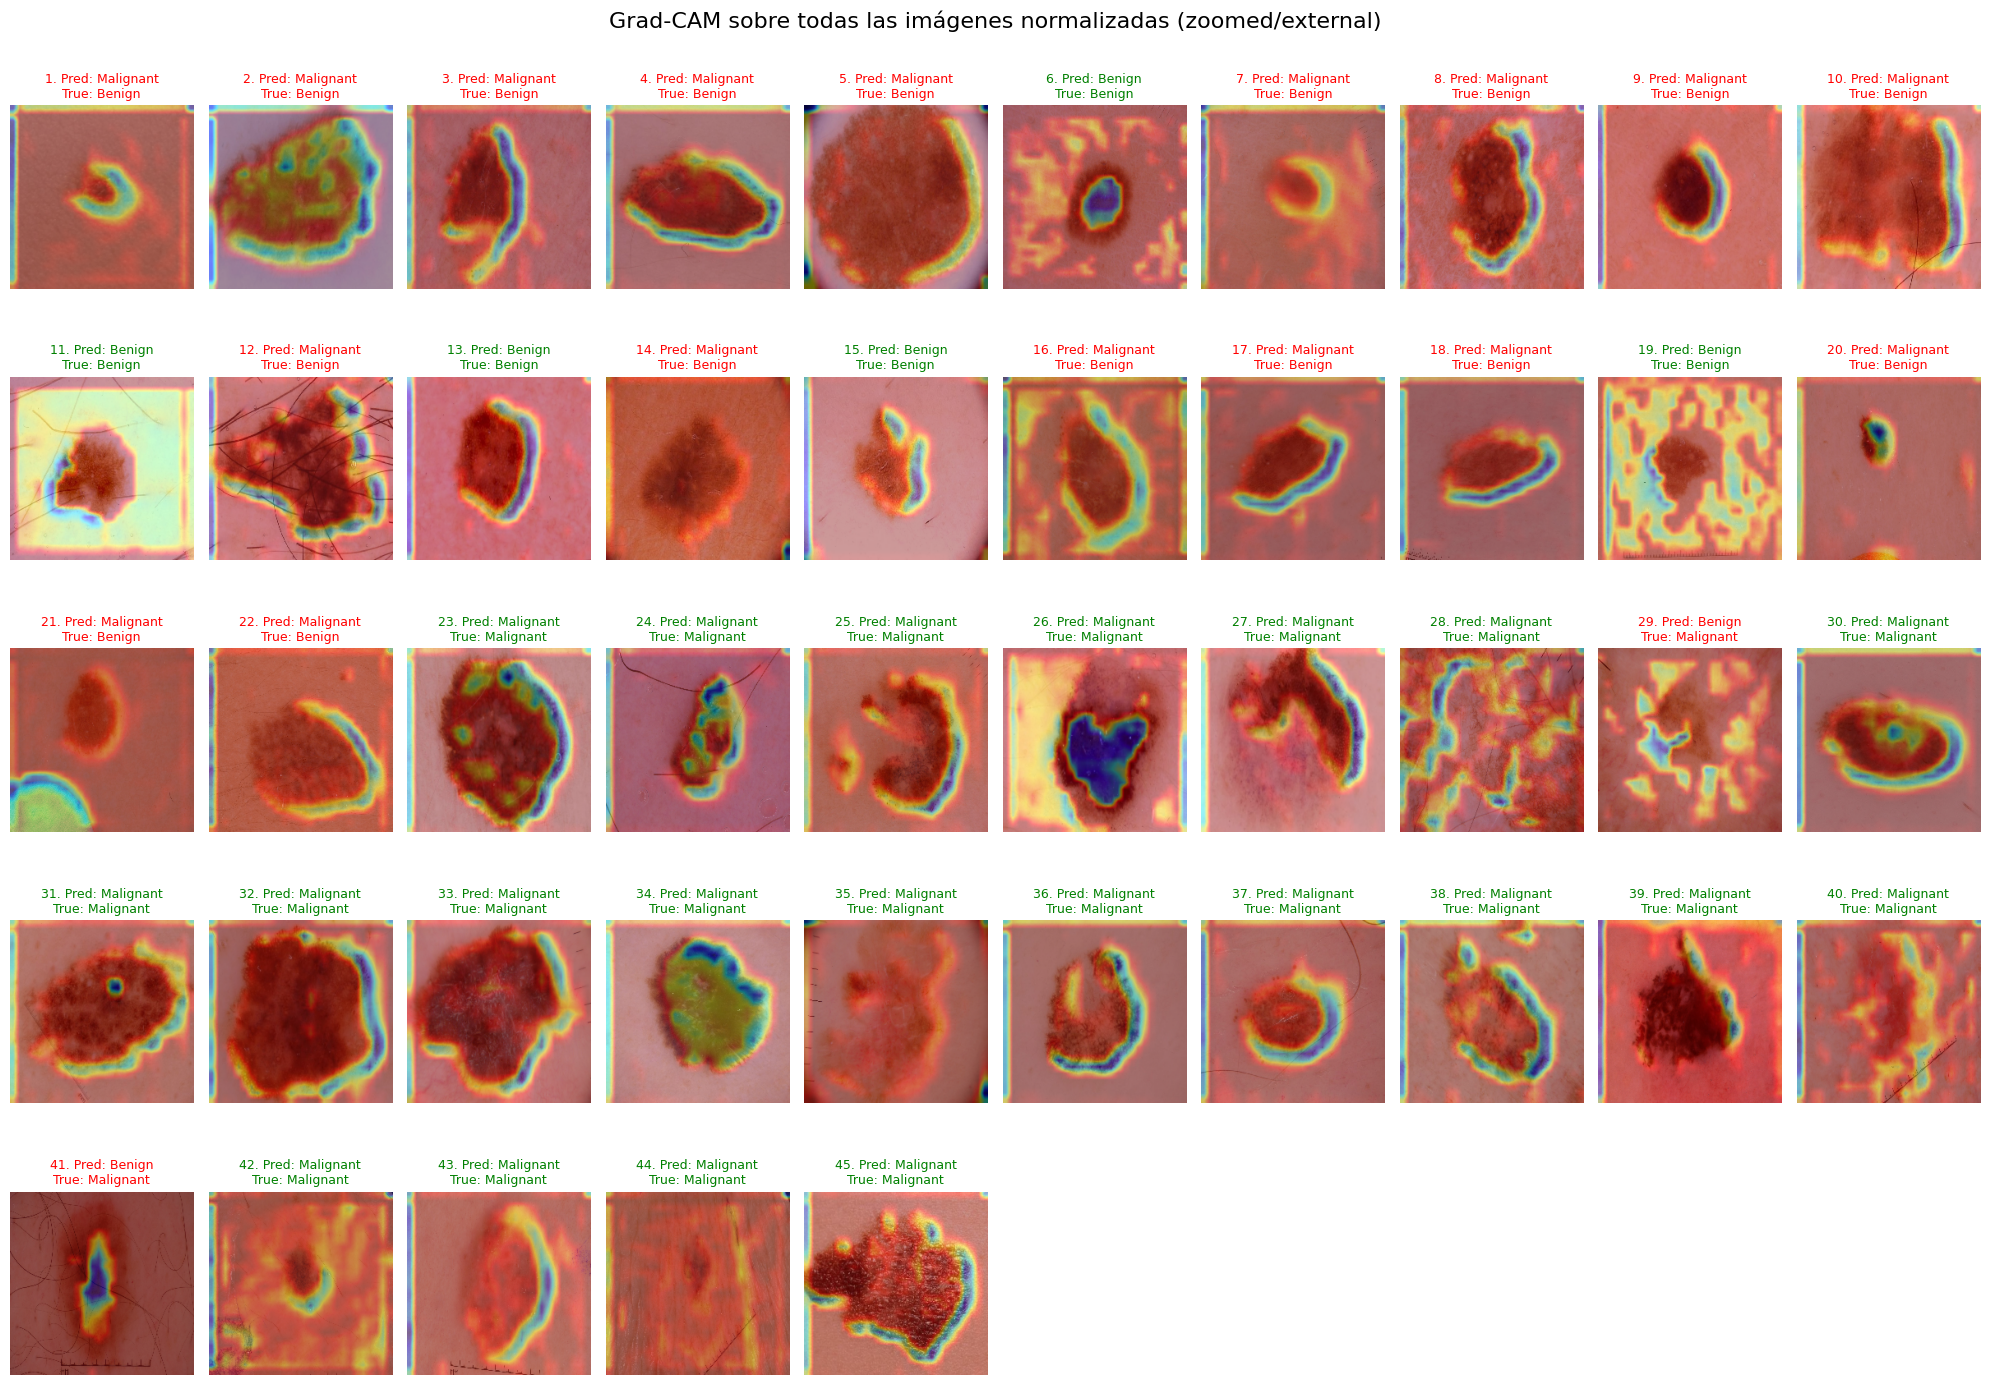

In [24]:
N = len(ext_gen.filenames)
rows, cols = 5, 10

plt.figure(figsize=(20, 14))
for i in range(N):
    img_path = os.path.join(external_dir, ext_gen.filenames[i])

    # leer y procesar imagen directamente desde disco
    img = tf.keras.utils.load_img(img_path, target_size=(ROWS, COLS))
    img_array = tf.keras.utils.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Grad-CAM
    heatmap = make_gradcam_heatmap(img_array, model_rgb_zoom, "conv4")
    heatmap = cv2.resize(heatmap, (ROWS, COLS))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = cv2.addWeighted((img_array[0] * 255).astype("uint8"), 0.6, heatmap, 0.4, 0)

    # Predicción y etiquetas
    pred = np.argmax(model_rgb_zoom.predict(img_array), axis=1)[0]
    label_pred = list(ext_gen.class_indices.keys())[pred]
    true_label = "Benign" if "Benign" in ext_gen.filenames[i] else "Malignant"

    color = "green" if label_pred == true_label else "red"
    plt.subplot(rows, cols, i + 1)
    plt.imshow(superimposed_img)
    plt.title(f"{i+1}. Pred: {label_pred}\nTrue: {true_label}", color=color, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.suptitle("Grad-CAM sobre todas las imágenes normalizadas (zoomed/external)", fontsize=16, y=1.02)
plt.show()

In [37]:
model_rgb_zoom.save("ZoomNet.keras")